<a href="https://colab.research.google.com/github/jasonhops/IE7374/blob/main/IE7374_Project_Model_Training_and_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IE7374 Group 12
AI Refrigerator Project

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import gdown
file_id = "13BJXv4_D-7eOGBLKZFjmNL0A-yFPKiHQ"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output="RecipeNLG_dataset.csv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13BJXv4_D-7eOGBLKZFjmNL0A-yFPKiHQ
From (redirected): https://drive.google.com/uc?id=13BJXv4_D-7eOGBLKZFjmNL0A-yFPKiHQ&confirm=t&uuid=5c0c0572-ed51-423d-81a0-1e5cac52e2d0
To: /content/RecipeNLG_dataset.csv
100%|██████████| 2.29G/2.29G [00:33<00:00, 67.9MB/s]


'RecipeNLG_dataset.csv'

In [3]:
import pandas as pd

df = pd.read_csv("RecipeNLG_dataset.csv")
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [4]:
import json

df["ingredients"] = df["ingredients"].apply(json.loads)
df["directions"] = df["directions"].apply(json.loads)

In [5]:
# Define common fridge items
dairy_items = {
    "milk", "cheese", "butter", "yogurt", "cream", "ghee", "curd", "kefir", "paneer", "ricotta",
    "parmesan", "mozzarella", "custard", "evaporatedmilk", "condensedmilk", "sourcream"
}
protein_items = {
    "egg", "bacon", "ham", "chicken", "turkey", "beef", "pork", "salmon", "tuna", "shrimp",
    "lamb", "duck", "steak", "sausage", "anchovy", "crab", "lobster", "mutton", "tilapia", "venison"
}
vegetable_items = {
    "lettuce", "spinach", "kale", "cabbage", "carrot", "onion", "garlic", "tomato", "pepper",
    "zucchini", "cucumber", "broccoli", "cauliflower", "celery", "radish", "turnip", "beet",
    "asparagus", "eggplant", "leek", "okra", "arugula", "parsley", "cilantro", "basil",
    "dill", "chard", "shallot", "scallion", "endive"
}
fungi_items = {
    "mushroom", "shiitake", "portobello", "enoki", "oyster", "cremini"
}
fruit_items = {
    "apple", "grape", "orange", "lemon", "lime", "pear", "peach", "banana", "mango", "blueberry",
    "strawberry", "raspberry", "blackberry", "plum", "apricot", "fig", "date", "melon", "kiwi", "pineapple"
}
grain_items = {
    "rice", "pasta", "noodle", "bread", "quinoa", "couscous", "oats", "barley", "flour", "tortilla",
    "corn", "bun", "bagel", "roll", "biscuit", "cracker", "crouton"
}
condiment_items = {
    "ketchup", "mustard", "mayonnaise", "relish", "vinegar", "sriracha", "pesto", "soy", "tamari",
    "miso", "salsa", "hummus", "tahini", "chutney", "aioli", "dressing", "gravy"
}
spice_items = {
    "salt", "pepper", "cumin", "turmeric", "paprika", "cinnamon", "nutmeg", "oregano",
    "thyme", "rosemary", "chili", "cardamom", "clove", "coriander", "sage"
}
nut_items = {
    "almond", "cashew", "walnut", "pecan", "hazelnut", "peanut", "pistachio", "chia", "flax", "sesame", "hemp"
}
beverage_items = {
    "juice", "soda", "cola", "water", "tea", "coffee", "kombucha", "smoothie", "lemonade"
}

fridge_items = (
    dairy_items |
    protein_items |
    vegetable_items |
    fungi_items |
    fruit_items |
    grain_items |
    condiment_items |
    spice_items |
    nut_items |
    beverage_items
)

#temporary shortlist
fridge_items = {
    "milk", "cheese", "cream cheese", "butter", "yogurt", "sour cream", "egg",
    "tomato", "onion", "lettuce", "spinach", "cabbage", "zucchini", "carrot",
    "garlic", "cucumber", "pepper", "celery", "apple", "grapes", "corn", "mushroom"
}

# Fridge inventory filter
def has_fridge_item(ingredients):
    match_count = sum(item.lower() in fridge_items for item in ingredients)
    return 2 <= len(ingredients) <= 10 and match_count >= 1

# Apply filter
df_subset = df[df["ingredients"].apply(has_fridge_item)].sample(frac=0.1, random_state=42)

In [6]:
# Convert ingredients and directions back to string
df_subset["text"] = df_subset.apply(
    lambda x: f"{', '.join(x['ingredients'])} -> {x['title'].strip()}. Instructions: {' '.join(x['directions']).strip()}",
    axis=1
)
df_subset = df_subset.dropna(subset=["text"])

In [7]:
df_subset["text"].to_csv("filtered_recipes_gpt.txt", index=False, header=False)

In [8]:
with open("filtered_recipes_gpt.txt", "r", encoding="utf-8") as f:
    contents = f.read()
    print(contents)
with open("filtered_recipes_gpt.txt", "r", encoding="utf-8") as file:
    lines = file.readlines()
    print("Number of rows:", len(lines))

"4 boneless pork chops, 2 to 3 Idaho potatoes, 1 large yellow onion, 1 green pepper, milk, salt and pepper -> Pork Chops And Scalloped Potatoes. Instructions: Peel and slice thinly the potatoes and place in a casserole dish. Thinly slice onion and pepper and mix with the potato slices. Add salt and freshly ground pepper to taste. Trim excess fat off the chops and lay chops on top of the vegetables. Add milk to top of potatoes. Cover and bake at 350° for 1 hour. Serves 4."
"1 medium-size eggplant, 1 can cream of mushroom soup, butter, milk or cream (I use the soup can of milk), crackers -> Eggplant Casserole. Instructions: Peel and cut eggplant into cubes. Cook in salt water until tender. Line a baking dish with crackers. Put alternate layers of crackers and eggplant. Cover with cream of mushroom soup into which milk or cream is added. Roll cracker crumbs and sprinkle on top. Dot with butter and sprinkle with paprika. Bake until brown."
"1 lb. hamburger, salt, pepper, chopped onions, su

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
from collections import Counter, defaultdict
import pickle
import os
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Download NLTK data for BLEU score
nltk.download('punkt', quiet=True)

True

In [10]:
# BPE Tokenizer
class BPETokenizer:
    def __init__(self, vocab_size=10257, special_tokens=['<pad>', '<eos>']):
        self.vocab_size = vocab_size
        self.special_tokens = special_tokens
        self.vocab = {}
        self.inv_vocab = {}
        self.merges = []
        self.byte_to_unicode = {i: chr(i) if 32 <= i < 127 else f'Ġ{i}' for i in range(256)}

    def train(self, texts):
        # Initialize with byte-level tokens
        corpus = []
        for text in texts:
            # Convert text to bytes and map to unicode
            bytes_text = text.encode('utf-8')
            tokens = [self.byte_to_unicode[b] for b in bytes_text]
            corpus.append(tokens)

        # Build initial vocabulary (single bytes)
        vocab = Counter()
        for tokens in corpus:
            vocab.update(tokens)
        self.vocab = {token: idx for idx, (token, _) in enumerate(vocab.items())}
        for idx, token in enumerate(self.special_tokens, len(self.vocab)):
            self.vocab[token] = idx
        self.inv_vocab = {idx: token for token, idx in self.vocab.items()}
        vocab_size = len(self.vocab)

        # Learn BPE merges
        while vocab_size < self.vocab_size:
            # Count pairs
            pair_counts = defaultdict(int)
            for tokens in corpus:
                for i in range(len(tokens)-1):
                    pair = (tokens[i], tokens[i+1])
                    pair_counts[pair] += 1
            if not pair_counts:
                break
            # Find most frequent pair
            best_pair = max(pair_counts, key=pair_counts.get)
            if pair_counts[best_pair] < 2:
                break
            # Merge pair
            new_token = best_pair[0] + best_pair[1]
            new_corpus = []
            for tokens in corpus:
                new_tokens = []
                i = 0
                while i < len(tokens):
                    if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == best_pair:
                        new_tokens.append(new_token)
                        i += 2
                    else:
                        new_tokens.append(tokens[i])
                        i += 1
                new_corpus.append(new_tokens)
            corpus = new_corpus
            # Update vocabulary
            self.vocab[new_token] = vocab_size
            self.inv_vocab[vocab_size] = new_token
            self.merges.append(best_pair)
            vocab_size += 1

        self.vocab_size = len(self.vocab)

    def encode(self, text, max_length=128):
        # Convert to bytes
        bytes_text = text.encode('utf-8')
        tokens = [self.byte_to_unicode[b] for b in bytes_text]
        # Apply merges
        for pair in self.merges:
            new_tokens = []
            i = 0
            while i < len(tokens):
                if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == pair:
                    new_tokens.append(pair[0] + pair[1])
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1
            tokens = new_tokens
        # Convert to token IDs
        token_ids = [self.vocab.get(token, self.vocab['<pad>']) for token in tokens]
        # Add EOS token
        token_ids.append(self.vocab['<eos>'])
        # Pad or truncate
        if len(token_ids) > max_length:
            token_ids = token_ids[:max_length]
        else:
            token_ids += [self.vocab['<pad>']] * (max_length - len(token_ids))
        return torch.tensor(token_ids, dtype=torch.long)

    def decode(self, token_ids, skip_special_tokens=True):
        tokens = []
        for idx in token_ids:
            if idx >= self.vocab_size:
                continue
            token = self.inv_vocab.get(idx.item(), '')
            if skip_special_tokens and token in self.special_tokens:
                continue
            tokens.append(token)
        # Convert tokens back to text
        text = ''.join(tokens)
        # Replace Ġ with space for readability
        text = re.sub(r'Ġ(\d+)', lambda m: chr(int(m.group(1))), text)
        return text

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({'vocab': self.vocab, 'merges': self.merges, 'byte_to_unicode': self.byte_to_unicode}, f)

    @classmethod
    def load(cls, path):
        tokenizer = cls()
        with open(path, 'rb') as f:
            data = pickle.load(f)
        tokenizer.vocab = data['vocab']
        tokenizer.merges = data['merges']
        tokenizer.byte_to_unicode = data['byte_to_unicode']
        tokenizer.inv_vocab = {idx: token for token, idx in tokenizer.vocab.items()}
        tokenizer.vocab_size = len(tokenizer.vocab)
        return tokenizer

# Simple GELU activation
class NewGELUActivation(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

# Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        var = x.var(-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

# Multi-Head Attention
class GPT2Attention(nn.Module):
    def __init__(self, d_model=768, n_heads=12, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.d_model, dim=-1)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        y = torch.matmul(attn, v)
        y = y.transpose(1, 2).contiguous().view(B, T, self.d_model)
        y = self.resid_dropout(self.c_proj(y))
        return y

# Feed-Forward Network
class GPT2MLP(nn.Module):
    def __init__(self, d_model=768, d_ff=3072, dropout=0.1):
        super().__init__()
        self.c_fc = nn.Linear(d_model, d_ff)
        self.c_proj = nn.Linear(d_ff, d_model)
        self.act = NewGELUActivation()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

# Transformer Block
class GPT2Block(nn.Module):
    def __init__(self, d_model=768, n_heads=12, d_ff=3072, dropout=0.1):
        super().__init__()
        self.ln_1 = LayerNorm(d_model, eps=1e-5)
        self.attn = GPT2Attention(d_model, n_heads, dropout)
        self.ln_2 = LayerNorm(d_model, eps=1e-5)
        self.mlp = GPT2MLP(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln_1(x), mask)
        x = x + self.mlp(self.ln_2(x))
        return x

# GPT-2 Model
class GPT2LMHeadModel(nn.Module):
    def __init__(self, vocab_size=50257, d_model=768, n_layers=12, n_heads=12, d_ff=3072, max_seq_len=1024, dropout=0.1):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, d_model)
        self.wpe = nn.Embedding(max_seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.h = nn.ModuleList([GPT2Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln_f = LayerNorm(d_model, eps=1e-5)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        self.max_seq_len = max_seq_len
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, LayerNorm):
            module.gamma.data.fill_(1.0)
            module.beta.data.zero_()

    def forward(self, input_ids, attention_mask=None, labels=None):
        B, T = input_ids.size()
        device = input_ids.device
        positions = torch.arange(0, T, device=device).unsqueeze(0)
        x = self.wte(input_ids) + self.wpe(positions)
        x = self.drop(x)
        if attention_mask is None:
            mask = torch.tril(torch.ones(T, T, device=device)).unsqueeze(0).unsqueeze(0)
        else:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
        for block in self.h:
            x = block(x, mask)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if labels is not None:
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(shift_logits.view(-1, logits.size(-1)), shift_labels.view(-1))
        return {'logits': logits, 'loss': loss}

    def generate(self, input_ids, max_length=100, temperature=0.6, top_k=50, top_p=0.9, repetition_penalty=1.2):
        self.eval()
        generated = input_ids.clone()
        device = input_ids.device
        with torch.no_grad():
            for _ in range(max_length - input_ids.size(1)):
                outputs = self(generated)
                next_token_logits = outputs['logits'][:, -1, :] / temperature
                for i in range(generated.size(0)):
                    for token in generated[i]:
                        next_token_logits[i, token] /= repetition_penalty
                if top_k > 0:
                    indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                    next_token_logits[indices_to_remove] = float('-inf')
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)
                    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                    sorted_indices_to_remove = cumulative_probs > top_p
                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0
                    indices_to_remove = sorted_indices[sorted_indices_to_remove]
                    next_token_logits[:, indices_to_remove] = float('-inf')
                probs = torch.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                generated = torch.cat((generated, next_token), dim=1)
                if next_token.item() == self.wte.num_embeddings - 1:  # EOS token
                    break
        return generated

# Recipe Dataset
class RecipeDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        input_ids = self.tokenizer.encode(text, self.max_length)
        attention_mask = (input_ids != self.tokenizer.vocab['<pad>']).long()
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

In [12]:
# Load data
with open('filtered_recipes_gpt.txt', 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

# Initialize and train tokenizer
tokenizer = BPETokenizer(vocab_size=2257) #50257
if not os.path.exists('tokenizer.pkl'):
    print('Training BPE tokenizer...')
    tokenizer.train(lines)
    tokenizer.save('tokenizer.pkl')
else:
    print('Loading BPE tokenizer...')
    tokenizer = BPETokenizer.load('tokenizer.pkl')



Training BPE tokenizer...


In [13]:
!ls -lh tokenizer.pkl

-rw-r--r-- 1 root root 44K Jul 26 16:02 tokenizer.pkl


In [14]:
from google.colab import files
files.download('tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Initialize dataset
dataset = RecipeDataset(lines, tokenizer, max_length=128)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GPT2LMHeadModel(vocab_size=tokenizer.vocab_size).to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# Load checkpoint if available
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
start_epoch = 0
if os.path.exists(os.path.join(checkpoint_dir, 'latest.pt')):
    checkpoint = torch.load(os.path.join(checkpoint_dir, 'latest.pt'))
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f'Resuming from epoch {start_epoch}')

In [16]:
# Training
epochs = 3
epoch_losses = []

for epoch in range(start_epoch, epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc=f'Epoch {epoch+1}'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=input_ids)
        loss = outputs['loss']
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    epoch_losses.append(avg_loss)
    print(f'Epoch {epoch+1} - Loss: {avg_loss:.4f}')
    # Save checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }
    torch.save(checkpoint, os.path.join(checkpoint_dir, f'epoch_{epoch+1}.pt'))
    torch.save(checkpoint, os.path.join(checkpoint_dir, 'latest.pt'))


Epoch 1: 100%|██████████| 1382/1382 [04:48<00:00,  4.79it/s]


Epoch 1 - Loss: 4.9496


Epoch 2: 100%|██████████| 1382/1382 [04:47<00:00,  4.80it/s]


Epoch 2 - Loss: 0.2847


Epoch 3: 100%|██████████| 1382/1382 [04:47<00:00,  4.80it/s]


Epoch 3 - Loss: 0.0168


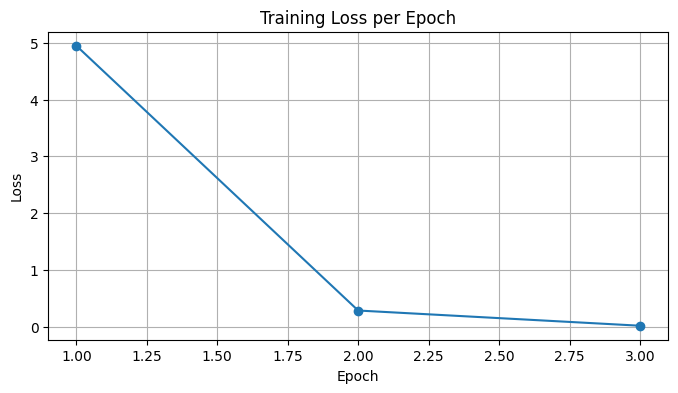

In [17]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(start_epoch+1, len(epoch_losses)+start_epoch+1), epoch_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('training_loss.png')
plt.show()
plt.close()


In [18]:
# Save final model
torch.save(model.state_dict(), 'gpt2_recipes.pt')
print('Final model saved to gpt2_recipes.pt')

Final model saved to gpt2_recipes.pt


**Model Testing**

In [26]:
# Testing
def test_model(prompt, max_length=100):
    model.eval()
    input_ids = tokenizer.encode(prompt, max_length=128).unsqueeze(0).to(device)
    print(f"Input IDs: {input_ids.tolist()}")  # Debug input tokens
    print(f"Input tokens: {[tokenizer.inv_vocab.get(idx.item(), 'UNK') for idx in input_ids[0]]}")  # Debug input tokens
    generated = model.generate(
        input_ids,
        max_length=max_length,
        temperature=0.6,
        top_k=50,
        top_p=0.9,
        repetition_penalty=1.2
    )
    print(f"Generated IDs: {generated.tolist()}")  # Debug generated tokens
    print(f"Generated tokens: {[tokenizer.inv_vocab.get(idx.item(), 'UNK') for idx in generated[0]]}")  # Debug generated tokens
    generated_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    output = generated_text[len(prompt):].strip() if len(generated_text) > len(prompt) else ""
    print(f'Prompt: {prompt}')
    print(f'Generated: {output}')

In [27]:
# Test prompts
test_model('cheese, tomato, lettuce -> ')
test_model('Ingredients: egg, flour, sugar → Recipe: ')
test_model('pepper, celery, apple, grapes, corn -> ')

Input IDs: [[997, 852, 122, 841, 1186, 120, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119, 119]]
Input tokens: ['cheese, ', 'tomato', ', ', 'lettuc', 'e -> ', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pa

In [21]:
test_model('sugar, flour, melted margarine, apples')

Prompt: sugar, flour, melted margarine, apples
Generated: 


In [22]:
# Perplexity and BLEU
def calculate_perplexity(text):
    model.eval()
    input_ids = tokenizer.encode(text, max_length=128).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs['loss']
    return math.exp(loss.item())

prompt = 'Ingredients: egg, flour, sugar → Recipe: '
reference = 'Pancake. Instructions: Mix egg, flour, and sugar. Fry until golden.'
input_ids = tokenizer.encode(prompt, max_length=128).unsqueeze(0).to(device)
generated = model.generate(input_ids, max_length=100, temperature=0.6, top_k=50, top_p=0.9, repetition_penalty=1.2)
generated_text = tokenizer.decode(generated[0], skip_special_tokens=True)
generated_cont = generated_text[len(prompt):].strip()

# BLEU score
smoothie = SmoothingFunction().method4
bleu = sentence_bleu([reference.split()], generated_cont.split(), smoothing_function=smoothie)

# Perplexity
full_text = prompt + ' ' + generated_cont
ppl = calculate_perplexity(full_text)

In [23]:
print(f'\nEvaluation for prompt: {prompt}')
print(f'Generated: {generated_cont}')
print(f'BLEU: {bleu:.3f}')
print(f'Perplexity: {ppl:.2f}')


Evaluation for prompt: Ingredients: egg, flour, sugar → Recipe: 
Generated: 
BLEU: 0.000
Perplexity: 3.48
